# Andmete puhastamine

## Sisukord

- Vajalike pakettide import ja seadistused
- Algandmete laadimine Google Sheets'ist
- Andmete esmane kirjeldus ja kontroll
- Vastuste kodeerimine
- Andmekvalideedi kontrollid
- Puhastatud andmete kirjeldus
- Andmete eksport

## Vajalike pakettide impordid ja seadistused

In [97]:
from typing import Callable

import gspread
import pandas as pd
import numpy as np
import duckdb
import re

## Andmete laadimine

In [105]:
# Autentimine
gc = gspread.service_account(filename="freanalyys-732d478588e9.json", scopes=gspread.auth.READONLY_SCOPES)

# Leia ja ava Google Sheets dokument ning selles vajalik tööleht
sh = gc.open("Uuring Tarbijate hoiakud tekstiilide liigiti kogumisel rõivastest ja kodutekstiilidest loobumisel (vastused)")

# Leia vastuste tööleht
vastused = sh.worksheet("Vormi vastused")
# Päri kõik vastused
data_raw  = pd.DataFrame(vastused.get_all_records())
data_raw = data_raw.replace('', np.nan)

# Leia vastuste koodide tööleht
v_koodid = sh.worksheet("Vastuste koodid")
# Päri kõik vastuste koodid
vastuste_koodid  = pd.DataFrame(v_koodid.get_all_records())

In [99]:
# Loo koopia andmete puhastamiseks
data_coded = data_raw.copy()

## Andmete esmane kontroll

In [100]:
print(f'Andmestiku suurus: {data_coded.shape}')
# print(data_coded.info())

# Leia palju on puuduvaid väärtuseid
missing = data_coded.isnull().sum()
missing_pct = (missing / len(data_coded)) * 100
print('Puuduvad väärtused:')
print(missing_pct)


Andmestiku suurus: (678, 44)
Puuduvad väärtused:
Vastaja_ID                                              0.000000
K1_aeg                                                  0.000000
K2_kontroll                                             0.000000
K3_vanus                                                0.000000
K4_sugu                                                 0.000000
K5_elukoht                                              0.000000
K6_keel                                                 0.000000
K7_sorteerimiskaitumine                                 0.000000
K8_teadmiste_hinnang                                    0.000000
K9_probleemi_tosidus                                    0.000000
K10_probleemi_tosidus_tapsustus                        82.153392
K11_teadlikkus                                          0.000000
K12_teadlikkus_tapsustus                               92.035398
K13_kommunikatsiooni_selgus                             0.589971
K14_tekstiilide_kogus                    

## Vastuste kodeerimine

### Abifunktsioonid

In [101]:
def kodeeri_vastus(kysimus: str):
    '''
    Kodeeri vastused analüüsiks - asenda vastuse tekst vastava koodiga.
    Kui vastus on "muu", salvesta originaaltekst eraldi veergu.
    '''
    # Leia küsimusele vastavad kood-vastus paarid
    mapping = vastuste_koodid[vastuste_koodid['Kysimus'] == kysimus][["Vastus", "Kood"]]
    # Loo dictionary leitud vastus-kood paaridest
    vastavused = mapping.set_index('Vastus')['Kood'].to_dict()
    
    # Leia vastava küsimuse valiku "muu" kood 
    muu_kood = None
    for vastus, kood in vastavused.items():
        if vastus.strip().lower() == 'muu':
            muu_kood = kood
            break
    
    # Kontrolli, kas vastus on vastuste ja koodide tabelist leitav
    def leia_kood(vastus):
        # Kontrolli, kas vastus on tühi või tekst "NULL". Siis ära tagasta midagi.
        if pd.isna(vastus) or vastus == '' or str(vastus).upper() == 'NULL':
            return None, ''
        # Kontrolli, kas vastus leidub sõnastikus
        if vastus in vastavused:
            # Kui jah, tagasta vastusele vastav kood
            return vastavused[vastus], ''
        else:
            # Kui ei, siis tagasta "muu" kood ja algne tekst
            return muu_kood, vastus
    
    # Rakenda mäpping
    tulemus = data_coded[kysimus].apply(leia_kood)
    # Kui "muu" on olemas, loo kaks veergu, muidu ainult üks
    if muu_kood is not None:
        data_coded[[kysimus, f'{kysimus}_muu_tekst']] = tulemus.apply(pd.Series)
    else:
        data_coded[kysimus] = tulemus.apply(lambda x: x[0] if isinstance(x, tuple) else x)
    
     # Muuda koodid -> Int64
    data_coded[kysimus] = data_coded[kysimus].astype('Int64')

In [102]:
def kodeeri_mitu_vastust(kysimus: str):
    '''
    Kodeeri mitu vastust sisaldav lahter eraldi binaarsetesse veergudesse.
    '''
    # Leia küsimuse vastused ja koodid
    mapping = vastuste_koodid[vastuste_koodid['Kysimus'] == kysimus][["Vastus", "Kood"]]
    vastavused = mapping.set_index('Vastus')['Kood'].to_dict()
    
    # Sorteeri vastused pikkuse järgi (pikimad enne), et vältida osalisi kattumisi
    sorteeritud_vastused = sorted(vastavused.keys(), key=len, reverse=True)
    
    # Leia "muu" kood
    muu_kood = None
    for vastus, kood in vastavused.items():
        if vastus.strip().lower() == 'muu':
            muu_kood = kood
            break
    
    # Loo binaarsed veerud iga vastuse jaoks
    for vastus, kood in vastavused.items():
        veerg = f'{kysimus}_{kood}'
        if veerg not in data_coded.columns:
            data_coded[veerg] = 0
    
    # Loo "muu" teksti veerg
    if f'{kysimus}_muu_tekst' not in data_coded.columns:
        data_coded[f'{kysimus}_muu_tekst'] = ''
    
    # Töötle iga rida
    for idx, sisu in data_coded[kysimus].items():
        # Jäta vahele tühjad
        if pd.isna(sisu) or sisu == '' or str(sisu).upper() == 'NULL':
            continue
        
        j22k = str(sisu)
        leitud = []
        
        # Otsi kõiki eeldefineeritud vastuseid
        for vastus in sorteeritud_vastused:
            if vastus in j22k:
                kood = vastavused[vastus]
                data_coded.loc[idx, f'{kysimus}_{kood}'] = 1
                leitud.append(vastus)
        
        # Eemalda leitud vastused
        for vastus in leitud:
            j22k = j22k.replace(vastus, '')
        
        # Mis jäi järele on "muu"
        muu_tekst = ','.join([v.strip() for v in j22k.split(',') if v.strip()])
        if muu_tekst and muu_kood:
            data_coded.loc[idx, f'{kysimus}_{muu_kood}'] = 1
            data_coded.loc[idx, f'{kysimus}_muu_tekst'] = muu_tekst
    
    # Kustuta algne veerg
    data_coded.drop(columns=[kysimus], inplace=True)


In [103]:
def paranda_elukoha_vead(elukoht: str) -> str:
    '''
    Tagasta teadaolevate kirjavigadega elukoha nimetuse asemel korrektne nimetus, kust on elukoha eest ning järelt eemaldatud üleliigsed tühikud.
    '''
    elukoht = elukoht.lower().strip()
    
    # Paranda enamlevinud kirjavead
    asendused = {
        "tln": "tallinn",
        "tallinm": "tallinn",
        "harjumas": "harjumaa",
        "hafjumas": "harjumaa",
        "hatjumaa": "harjumaa",
        "pärjumaa": "pärnumaa",
        "jõheva": "jõgeva",
        "l-viru": "lääne-virumaa",
        "ida-virimaa": "ida-virumaa",
        "jarva maa": "järvamaa",
        "parnu": "pärnu",
        "järva jaani": "järva-jaani"
    }
    
    for k, v in asendused.items():
        elukoht = elukoht.replace(k, v)
    
    return elukoht

# Teadaolevate maakonna kirjapiltide vastavuspaarid
maakonnad = {
    "harjumaa": "Harju maakond",
    "harju maakond": "Harju maakond",
    "harju mk": "Harju maakond",
    "harju": "Harju maakond",
    "hiiumaa": "Hiiu maakond",
    "hiiu maakond": "Hiiu maakond",
    "ida-virumaa": "Ida-Viru maakond",
    "ida-viru maakond": "Ida-Viru maakond",
    "ida-viru": "Ida-Viru maakond",
    "jõgevamaa": "Jõgeva maakond",
    "jõgeva maakond": "Jõgeva maakond",
    "järvamaa": "Järva maakond",
    "järva maakond": "Järva maakond",
    "läänemaa": "Lääne maakond",
    "lääne maakond": "Lääne maakond",
    "lääne-virumaa": "Lääne-Viru maakond",
    "lääne-viru maakond": "Lääne-Viru maakond",
    "lääne-viru": "Lääne-Viru maakond",
    "põlvamaa": "Põlva maakond",
    "põlva maakond": "Põlva maakond",
    "pärnumaa": "Pärnu maakond",
    "pärnu maakond": "Pärnu maakond",
    "raplamaa": "Rapla maakond",
    "rapla maakond": "Rapla maakond",
    "saaremaa": "Saare maakond",
    "saare maakond": "Saare maakond",
    "tartumaa": "Tartu maakond",
    "tartu maakond": "Tartu maakond",
    "valgamaa": "Valga maakond",
    "valga maakond": "Valga maakond",
    "viljandimaa": "Viljandi maakond",
    "viljandi maakond": "Viljandi maakond",
    "võrumaa": "Võru maakond",
    "võru maakond": "Võru maakond"
}

# Linna ja maakonna vastavuspaarid
elukoht_maakond = {
    # Harjumaa
    "tallinn": "Harju maakond",
    "keila": "Harju maakond",
    "maardu": "Harju maakond",
    "paldiski": "Harju maakond",
    "viimsi": "Harju maakond",
    "saku": "Harju maakond",
    "saue": "Harju maakond",
    "rae": "Harju maakond",
    "harku": "Harju maakond",
    "lääne-harju": "Harju maakond",
    "klooga": "Harju maakond",
    "rummu": "Harju maakond",
    "padise": "Harju maakond",
    # Ida-Virumaa
    "jõhvi": "Ida-Viru maakond",
    # Jõgevamaa
    "jõgeva": "Jõgeva maakond",
    "luua": "Jõgeva maakond",
    "põltsamaa": "Jõgeva maakond",
    # Järvamaa
    "järva-jaani": "Järva maakond",
    "järva vald": "Järva maakond",
    # Lääne-Virumaa
    "rakvere": "Lääne-Viru maakond",
    # Põlvamaa
    "põlva": "Põlva maakond",
    # Pärnumaa
    "pärnu": "Pärnu maakond",
    "sindi": "Pärnu maakond",
    # Raplamaa
    "rapla": "Rapla maakond",
    "raka": "Rapla maakond",
    # Tartumaa
    "tartu": "Tartu maakond",
    "ülenurme": "Tartu maakond",
    "kambja": "Tartu maakond",
    # Valgamaa
    "valga": "Valga maakond",
    # Viljandimaa
    "viljandi": "Viljandi maakond",
    "põhja-sakala": "Viljandi maakond"
}

def tuleta_maakond(tekst: str) -> str:
    '''
    Tagasta etteantud sõnastike alusel vastaja elukoha maakond
    '''
    elukoht = paranda_elukoha_vead(tekst)
    elukohad = re.split(r"[,/]| ja ", elukoht)
    peamine_elukoht = elukohad[0].strip()

    # Otsi maakondade hulgast ja tagasta korrektne nimetus
    for i in maakonnad:
        if i in peamine_elukoht:
            return maakonnad[i]

    # Otsi asukohrade hulgast ja tagasta vastav maakond
    for i in elukoht_maakond:
        if i in peamine_elukoht:
            return elukoht_maakond[i]

    return "Muu"

data_coded['K5_elukoht'] = data_coded['K5_elukoht'].apply(tuleta_maakond)

## Ühe vastusevariandiga andmeväljade kodeerimine

In [104]:
kodeeri_vastus('K2_kontroll')
kodeeri_vastus('K3_vanus')
kodeeri_vastus('K4_sugu')
kodeeri_vastus('K5_elukoht')
kodeeri_vastus('K6_keel')
kodeeri_vastus('K7_sorteerimiskaitumine')
kodeeri_vastus('K11_teadlikkus')
kodeeri_vastus('K13_kommunikatsiooni_selgus')
kodeeri_vastus('K14_tekstiilide_kogus')
kodeeri_vastus('K26_korduskasutuseks_sobimatud_tekstiilid')
kodeeri_vastus('K28_riikliku_juhise_selgus')
kodeeri_vastus('K29_sobiv_kogumisviis')
kodeeri_vastus('K30_valmisolek_kategoriseerimiseks')
kodeeri_vastus('K36_valmisolek_lisakysimusteks')
kodeeri_vastus('K38_kandmise_kestus')
kodeeri_vastus('K40_ostmissagedus')

KeyError: 'Kysimus'

## Mitme vastusevariandiga andmeväljade kodeerimine

In [ ]:
kodeeri_mitu_vastust('K15_mittevajalikud_tekstiilid')
kodeeri_mitu_vastust('K19_loobumise_pohjused')
kodeeri_mitu_vastust('K22_peamised_valjakutsed')
kodeeri_mitu_vastust('K23_kasutuskolbmatud_tekstiilid')
kodeeri_mitu_vastust('K25_loobumisel_oluline')
kodeeri_mitu_vastust('K32_teabe_allikad')
kodeeri_mitu_vastust('K33_julgustavad_tegurid')

# Teisenduste kontroll

In [ ]:
occur_raw = data_raw.groupby(['K28_riikliku_juhise_selgus']).size()
print(occur_raw)

K28_riikliku_juhise_selgus
1                                 5
2                                10
3                                15
4                                 3
Ei ole sellega kursis/ei tea    293
Osaliselt arusaadav             135
Osaliselt arusaamatu            119
Täiesti arusaadav                26
Täiesti arusaamatu               69
dtype: int64


In [ ]:
occur = data_coded.groupby(['K28_riikliku_juhise_selgus']).size()
print(occur)

K28_riikliku_juhise_selgus
1     66
2    118
3    135
4     25
5    292
dtype: int64


## Kvaliteedi kontrollid

In [ ]:
# Leia read, kus kontrollküsimuse vastus on "ei"
print(data_coded[data_coded['K2_kontroll'] != 1])

     Vastaja_ID              K1_aeg  K2_kontroll  K3_vanus  K4_sugu  \
181         182  3/13/2025 10:34:54            2         1        2   
275         276  3/13/2025 10:32:19            2         5        3   
322         323  4/13/2025 13:12:15            2         3        1   
656         657  3/13/2025 10:38:41            2         5        3   
661         662   3/12/2025 0:53:24            2         4        3   

     K5_elukoht  K6_keel  K7_sorteerimiskaitumine  K8_teadmiste_hinnang  \
181           4        1                        3                     1   
275          16        3                        2                     1   
322          16        4                        3                     1   
656          16        1                        1                     1   
661          16        1                        4                     5   

     K9_probleemi_tosidus  ... K32_teabe_allikad_10  \
181                     3  ...                    0   
275         

In [ ]:
# Eemalda read, kus kontrollküsimuse vastus "ei"
data_coded = data_coded[data_coded['K2_kontroll'] == 1]

print(f"Kontrollküsimuse alusel ridade eemaldamise järel jäi alles: {len(data_coded)} rida")

Alles jäi: 673 rida


In [ ]:
# Muuda aja formaat -> datetime
data_coded['K1_aeg'] = pd.to_datetime(data_coded['K1_aeg'])

# Leia read, mis on väljaspool küsitluse perioodi
print(data_coded[(data_coded['K1_aeg'] < '2025-03-10') | (data_coded['K1_aeg'] > '2025-04-30')])

     Vastaja_ID              K1_aeg  K2_kontroll  K3_vanus  K4_sugu  \
347         348 2024-11-09 17:46:31            1         3        1   
348         349 2024-11-14 15:36:53            1         2        2   
349         350 2025-02-20 07:53:49            1         3        2   
397         398 2025-04-30 13:50:49            1         4        2   
586         587 2025-05-08 22:30:45            1         3        2   
643         644 2024-11-15 19:59:42            1         3        2   

     K5_elukoht  K6_keel  K7_sorteerimiskaitumine  K8_teadmiste_hinnang  \
347          16        1                        5                     5   
348          14        1                        2                     2   
349           9        1                        3                     4   
397          14        1                        3                     4   
586           1        1                        3                     3   
643           1        3                        3   

In [ ]:
# Eemalda read, mis on väljaspool küsitluse perioodi
data_coded = data_coded[data_coded['K1_aeg'].between('2025-03-10', '2025-04-30 23:59:59')]

print(f"Väljapool uuringu perioodi esinenud vastuste eemaldamise järel jäi alles: {len(data_coded)} rida")

Alles jäi: 668 rida


In [ ]:
# Kontrolli, kas samal ajahetkel on sama inimese kohta mitu vastust
duplicates = data_coded.duplicated(subset=['K1_aeg', 'K3_vanus', 'K4_sugu', 'K5_elukoht'], keep=False)
print(data_coded[duplicates])


Empty DataFrame
Columns: [Vastaja_ID, K1_aeg, K2_kontroll, K3_vanus, K4_sugu, K5_elukoht, K6_keel, K7_sorteerimiskaitumine, K8_teadmiste_hinnang, K9_probleemi_tosidus, K10_probleemi_tosidus_tapsustus, K11_teadlikkus, K12_teadlikkus_tapsustus, K13_kommunikatsiooni_selgus, K14_tekstiilide_kogus, K16_mittevajalikud_tekstiilid_tapsustus, K17_valmisolek_parandamiseks, K18_valmisolek_parandamiseks_tapsustus, K20_loobumise_pohjused_tapsustus, K21_loobumise_lihtsus, K24_kasutuskolbmatud_tekstiilid_tapsustus, K26_korduskasutuseks_sobimatud_tekstiilid, K27_korduskasutuseks_sobimatud_tekstiilid_tapsustus, K28_riikliku_juhise_selgus, K29_sobiv_kogumisviis, K30_valmisolek_kategoriseerimiseks, K31_valmisolek_kategoriseerimiseks_tapsustus, K34_ettepanekud, K35_valmisolek_telefonikoneks, K36_valmisolek_lisakysimusteks, K37_rahulolu_garderoobiga, K38_kandmise_kestus, K39_kandmise_kestus_tapsustus, K40_ostmissagedus, K41_ultrakiirmoe_ostmine, K42_ultrakiirmoe_eelistamise_pohjused, K43_roivaste_tellimine

In [ ]:
# Eemalda duplikaadid
data_coded.drop_duplicates(subset=['K1_aeg', 'K3_vanus', 'K4_sugu', 'K5_elukoht'], keep='last', inplace = True)
print(f"Duplikaatide eemaldamise järel jäi alles: {len(data_coded)} rida")

Alles jäi: 668 rida


## Kokkuvõttev statistika

In [ ]:
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
# pd.reset_option('max_columns')

In [ ]:
# Uuringu periood
print(f'Uuringu algus: {min(data_coded.K1_aeg)}')
print(f'Uuringu lõpp: {max(data_coded.K1_aeg)}')

Uuringu algus: 2025-03-10 08:01:13
Uuringu lõpp: 2025-04-30 13:50:49


In [ ]:
# Andmestiku eelvaade
display(data_coded.head(20))

,Vastaja_ID,K1_aeg,K2_kontroll,K3_vanus,K4_sugu,K5_elukoht,K6_keel,K7_sorteerimiskaitumine,K8_teadmiste_hinnang,K9_probleemi_tosidus,K10_probleemi_tosidus_tapsustus,K11_teadlikkus,K12_teadlikkus_tapsustus,K13_kommunikatsiooni_selgus,K14_tekstiilide_kogus,K16_mittevajalikud_tekstiilid_tapsustus,K17_valmisolek_parandamiseks,K18_valmisolek_parandamiseks_tapsustus,K20_loobumise_pohjused_tapsustus,K21_loobumise_lihtsus,K24_kasutuskolbmatud_tekstiilid_tapsustus,K26_korduskasutuseks_sobimatud_tekstiilid,K27_korduskasutuseks_sobimatud_tekstiilid_tapsustus,K28_riikliku_juhise_selgus,K29_sobiv_kogumisviis,K30_valmisolek_kategoriseerimiseks,K31_valmisolek_kategoriseerimiseks_tapsustus,K34_ettepanekud,K35_valmisolek_telefonikoneks,K36_valmisolek_lisakysimusteks,K37_rahulolu_garderoobiga,K38_kandmise_kestus,K39_kandmise_kestus_tapsustus,K40_ostmissagedus,K41_ultrakiirmoe_ostmine,K42_ultrakiirmoe_eelistamise_pohjused,K43_roivaste_tellimine_proovimiseks,K5_elukoht_muu_tekst,K6_keel_muu_tekst,K7_sorteerimiskaitumine_muu_tekst,K14_tekstiilide_kogus_muu_tekst,K29_sobiv_kogumisviis_muu_tekst,K30_valmisolek_kategoriseerimiseks_muu_tekst,K38_kandmise_kestus_muu_tekst,K15_mittevajalikud_tekstiilid_1,K15_mittevajalikud_tekstiilid_2,K15_mittevajalikud_tekstiilid_3,K15_mittevajalikud_tekstiilid_4,K15_mittevajalikud_tekstiilid_5,K15_mittevajalikud_tekstiilid_6,K15_mittevajalikud_tekstiilid_7,K15_mittevajalikud_tekstiilid_muu_tekst,K19_loobumise_pohjused_1,K19_loobumise_pohjused_2,K19_loobumise_pohjused_3,K19_loobumise_pohjused_4,K19_loobumise_pohjused_5,K19_loobumise_pohjused_6,K19_loobumise_pohjused_7,K19_loobumise_pohjused_8,K19_loobumise_pohjused_9,K19_loobumise_pohjused_muu_tekst,K22_peamised_valjakutsed_1,K22_peamised_valjakutsed_2,K22_peamised_valjakutsed_3,K22_peamised_valjakutsed_4,K22_peamised_valjakutsed_5,K22_peamised_valjakutsed_6,K22_peamised_valjakutsed_7,K22_peamised_valjakutsed_muu_tekst,K23_kasutuskolbmatud_tekstiilid_1,K23_kasutuskolbmatud_tekstiilid_2,K23_kasutuskolbmatud_tekstiilid_3,K23_kasutuskolbmatud_tekstiilid_4,K23_kasutuskolbmatud_tekstiilid_5,K23_kasutuskolbmatud_tekstiilid_6,K23_kasutuskolbmatud_tekstiilid_7,K23_kasutuskolbmatud_tekstiilid_muu_tekst,K25_loobumisel_oluline_1,K25_loobumisel_oluline_2,K25_loobumisel_oluline_3,K25_loobumisel_oluline_4,K25_loobumisel_oluline_5,K25_loobumisel_oluline_6,K25_loobumisel_oluline_7,K25_loobumisel_oluline_muu_tekst,K32_teabe_allikad_1,K32_teabe_allikad_2,K32_teabe_allikad_3,K32_teabe_allikad_4,K32_teabe_allikad_5,K32_teabe_allikad_6,K32_teabe_allikad_7,K32_teabe_allikad_8,K32_teabe_allikad_9,K32_teabe_allikad_10,K32_teabe_allikad_muu_tekst,K33_julgustavad_tegurid_1,K33_julgustavad_tegurid_2,K33_julgustavad_tegurid_3,K33_julgustavad_tegurid_4,K33_julgustavad_tegurid_5,K33_julgustavad_tegurid_6,K33_julgustavad_tegurid_7,K33_julgustavad_tegurid_muu_tekst
0,1,2025-03-10 08:01:13,1,2,2,1,1,2,5,5,NaN,1,NaN,2,2,NaN,2,NaN,NaN,3,NaN,2,NaN,<NA>,1,3,NaN,NaN,ei,1,4,1,NaN,4,1,NaN,2,,,,,,,,1,0,1,1,0,0,1,Annetused suurperedele,1,0,0,1,0,1,0,0,0,,0,1,0,0,1,0,0,,1,1,1,0,0,0,0,,1,0,1,1,1,0,0,,1,0,0,0,0,1,0,1,0,0,,1,1,1,1,0,1,0,
1,2,2025-03-10 16:55:18,1,2,2,9,1,3,3,3,Viimastel aastatel kasutatud asjade ost popula...,4,NaN,4,7,NaN,4,NaN,NaN,3,NaN,3,NaN,<NA>,6,4,NaN,NaN,Ei,1,5,5,NaN,5,3,"Odavam hind, võid saada parema asja kui Eesti ...",1,,,,"4-liikmelise pere peale aastas, kus kiirelt ka...",Siiski esimene variant kindlalt ja mobiilne va...,,"Peaaegu ei loobugi, mul hetkel on ainus paar r...",1,0,1,1,0,1,1,"Kui on nii räbal,et ei anna tuunida,siis prügisse",0,1,0,0,0,1,1,0,0,,0,0,1,1,0,0,0,,0,1,0,0,0,0,1,Mina olen siiani ainult Tallinnas näinud katki...,1,0,0,0,1,0,0,,0,0,0,0,0,1,0,0,0,0,,1,1,0,0,0,0,0,
2,3,2025-03-17 21:06:37,1,4,2,1,1,2,4,5,NaN,4,NaN,4,7,NaN,3,NaN,NaN,1,NaN,3,NaN,5,5,3,NaN,"Väga suur probleem on vanadel inimestel, nad e...",Ei,2,NaN,<NA>,NaN,<NA>,NaN,NaN,NaN,,,,5kg aastas,,,,0,0,1,1,0,0,1,Kasutan koristamisel,0,0,1,0,1,1,0,0,0,,1,0,1,0,1,0,1,Sorteerimisjubenditest ei ole kuulnud,1,0,1

In [ ]:
# Andmestiku üldine info
print("Andmestiku dimensioonid: ", data_coded.shape)

print('Andmestiku üldine info:')
print(data_coded.info(verbose='True'))

Andmestiku dimensioonid:  (668, 105)
Andmetüübid:
Vastaja_ID                                                      int64
K1_aeg                                                 datetime64[us]
K2_kontroll                                                     Int64
K3_vanus                                                        Int64
K4_sugu                                                         Int64
K5_elukoht                                                      Int64
K6_keel                                                         Int64
K7_sorteerimiskaitumine                                         Int64
K8_teadmiste_hinnang                                            int64
K9_probleemi_tosidus                                            int64
K10_probleemi_tosidus_tapsustus                                object
K11_teadlikkus                                                  Int64
K12_teadlikkus_tapsustus                                          str
K13_kommunikatsiooni_selgus             

In [ ]:
print('Andmestiku detailne kirjeldus:')
print(data_coded.describe(include='all'))
# data_coded.describe(include='all').to_csv('describe_output.csv', encoding='utf-8')

        Vastaja_ID                      K1_aeg  K2_kontroll  K3_vanus  \
count   668.000000                         668        668.0     668.0   
unique         NaN                         NaN         <NA>      <NA>   
top            NaN                         NaN         <NA>      <NA>   
freq           NaN                         NaN         <NA>      <NA>   
mean    338.028443  2025-03-21 03:45:45.422156          1.0  2.838323   
min       1.000000         2025-03-10 08:01:13          1.0       1.0   
25%     167.750000  2025-03-13 10:22:43.750000          1.0       2.0   
50%     337.500000         2025-03-18 17:00:57          1.0       3.0   
75%     507.250000  2025-03-20 17:05:11.500000          1.0       3.0   
max     678.000000         2025-04-30 13:50:49          1.0       5.0   
std     195.843122                         NaN          0.0  0.857578   

         K4_sugu  K5_elukoht   K6_keel  K7_sorteerimiskaitumine  \
count      668.0       668.0     668.0                  

Tühjade väärtuse esinemine veergude kaupa:
Vastaja_ID                                               0
K1_aeg                                                   0
K2_kontroll                                              0
K3_vanus                                                 0
K4_sugu                                                  0
K5_elukoht                                               0
K6_keel                                                  0
K7_sorteerimiskaitumine                                  0
K8_teadmiste_hinnang                                     0
K9_probleemi_tosidus                                     0
K10_probleemi_tosidus_tapsustus                        551
K11_teadlikkus                                           0
K12_teadlikkus_tapsustus                               617
K13_kommunikatsiooni_selgus                              0
K14_tekstiilide_kogus                                    0
K16_mittevajalikud_tekstiilid_tapsustus                587
K17_valmisole

<Axes: >

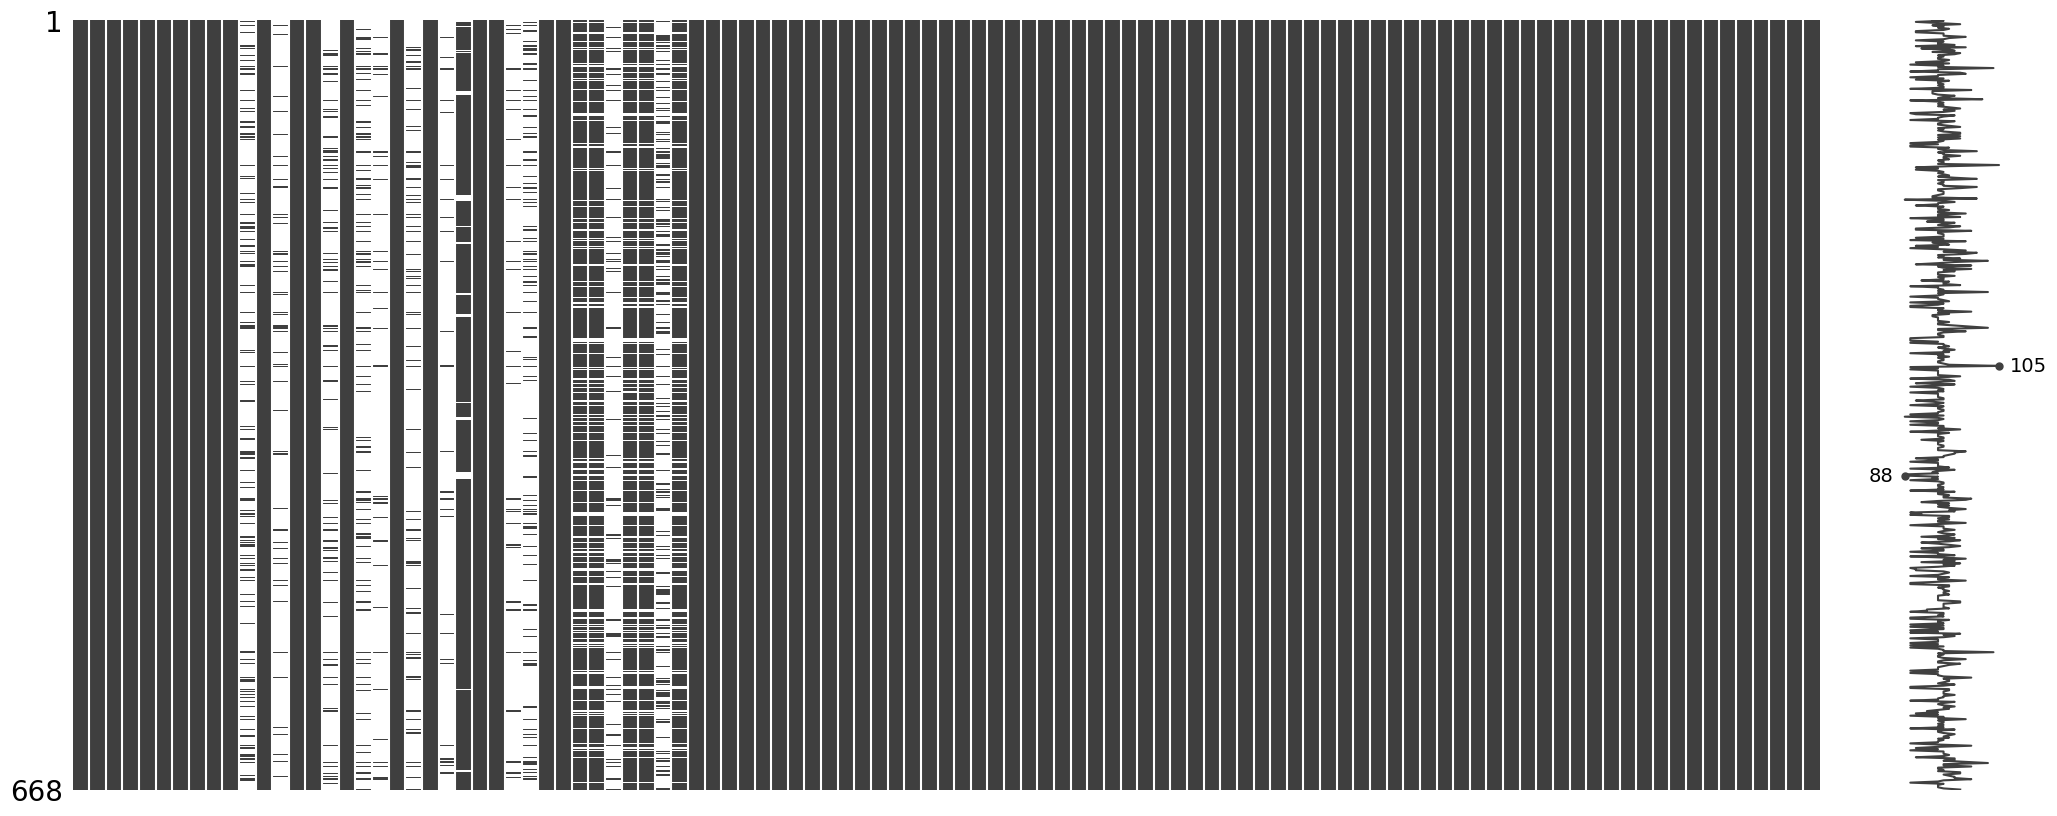

In [ ]:
# Tühjade väärtuste esinemine
print('Tühjade väärtuse esinemine veergude kaupa:')
print(data_coded.isnull().sum())
# print(data_coded.nunique())

# Visualiseeri puuduvate väärtuste mustrid
import missingno as msno
msno.matrix(data_coded)

## Puhastatud andmete eksport

In [107]:
# Ekspordi andmed CSV faili
data_coded.to_csv('data/cleaned_data.csv', index=False, encoding='utf-8')

vastuste_koodid.to_csv('data/vastuste_koodid.csv', index=False, encoding='utf-8')